# 05 - Orbital Economics
Deployment cost vs junction temperature and launch cost per kg.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
from simulations.sensitivity_analysis import junction_vs_launchcost_grid
tj = np.linspace(400, 1080, 25)
lc = np.array([100, 300, 500, 1500, 2700])
grid = junction_vs_launchcost_grid(100e6, 100e6, tj, lc)
grid.head()

,junction_temp_k,launch_cost_usd_per_kg,radiator_area_m2,radiator_mass_kg,total_mass_kg,deployment_cost_usd,cost_per_mw_usd
0,400.0,100.0,73225.604128,512579.228893,1.204246e+06,1.204246e+08,1.204246e+06
1,400.0,300.0,73225.604128,512579.228893,1.204246e+06,3.612738e+08,3.612738e+06
2,400.0,500.0,73225.604128,512579.228893,1.204246e+06,6.021229e+08,6.021229e+06
3,400.0,1500.0,73225.604128,512579.228893,1.204246e+06,1.806369e+09,1.806369e+07
4,400.0,2700.0,73225.604128,512579.228893,1.204246e+06,3.251464e+09,3.251464e+07


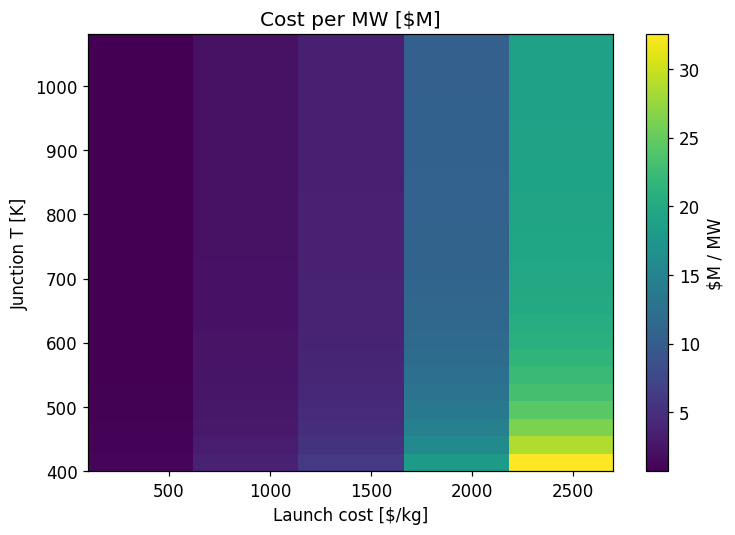

In [2]:
pivot = grid.pivot(index='junction_temp_k', columns='launch_cost_usd_per_kg', values='cost_per_mw_usd')
fig, ax = plt.subplots(figsize=(7,5))
im = ax.imshow(pivot.values/1e6, aspect='auto', origin='lower',
               extent=[lc.min(), lc.max(), tj.min(), tj.max()], cmap='viridis')
ax.set_xlabel('Launch cost [$/kg]'); ax.set_ylabel('Junction T [K]')
ax.set_title('Cost per MW [$M]'); fig.colorbar(im, label='$M / MW')
plt.tight_layout(); plt.show()